# Génération des jeux de features pour les modèles de Machine Learning — Analyse à 3 classes

Ce notebook extrait un ensemble de caractéristiques numériques à partir des images issues du pipeline de prétraitement complet dédié à l’analyse à trois classes.

Les données utilisées correspondent aux trois jeux créés après le split du dataset prétraité :

- `COVID-19_Radiography_Dataset_split_3classes/train`
- `COVID-19_Radiography_Dataset_split_3classes/validation`
- `COVID-19_Radiography_Dataset_split_3classes/test`

Les classes finales sont :

- `COVID`
- `Normal`
- `Pneumonia`

La classe `Pneumonia` résulte de la fusion des classes initiales `Lung_Opacity` et `Viral Pneumonia`.

Remarque : la data augmentation est réservée aux modèles de Deep Learning dans le cadre de ce projet. Le jeu `train` utilisé ici correspond donc aux images d’entraînement non augmentées.

Les images utilisées ont préalablement subi les étapes suivantes : suppression des doublons et des outliers, redimensionnement, application du masque pulmonaire, égalisation globale de l’histogramme (`equalizeHist`), puis normalisation locale par CLAHE.

Les masques binaires d’origine sont chargés depuis `COVID-19_Radiography_Dataset` (`<classe_source>/masks/<image>.png`). Pour les images appartenant à la classe fusionnée `Pneumonia`, la classe source du masque est déterminée à partir du nom du fichier afin de retrouver le masque dans le dossier `Lung_Opacity` ou `Viral Pneumonia`.

Lorsque les dimensions du masque diffèrent de celles de l’image prétraitée, le masque est automatiquement redimensionné afin de permettre le calcul des caractéristiques au sein de la région pulmonaire.

Les variables extraites pour chaque image sont :

- `lum_interieur_masque` : intensité moyenne des pixels situés à l’intérieur du masque pulmonaire ;
- `lum_exterieur_masque` : intensité moyenne des pixels situés à l’extérieur du masque ;
- `surface_masque` : proportion de l’image occupée par les poumons ;
- `variance_laplacien` : mesure de la netteté de l’image basée sur la variance du Laplacien.

Les sorties attendues sont trois fichiers de features spécifiques à l’analyse à trois classes :

- `train_features_3classes.csv`
- `validation_features_3classes.csv`
- `test_features_3classes.csv`

Ces fichiers serviront à entraîner et évaluer les modèles de Machine Learning classiques, notamment la régression logistique, le Linear SVM, le KNN et le Random Forest.

In [1]:
# Chargement des bibliothèques
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# Chemins d'accès — analyse à 3 classes

split_path = Path(
    r"C:\Users\n_a_e\Documents\DataScientest\Data Scientist"
    r"\Projet COVID\COVID-19_Radiography_Dataset_split_3classes"
)

# Dataset source déjà nettoyé contenant les masques d'origine
masks_path = Path(
    r"C:\Users\n_a_e\Documents\DataScientest\Data Scientist"
    r"\Projet COVID\COVID-19_Radiography_Dataset"
)

# Dossier de sortie des CSV de features
output_dir = Path(
    r"C:\Users\n_a_e\Documents\DataScientest\Data Scientist"
    r"\Projet COVID\features"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Fichiers spécifiques à l'analyse à 3 classes
output_csv = {
    "train": (
        output_dir
        / "train_features_3classes.csv"
    ),
    "validation": (
        output_dir
        / "validation_features_3classes.csv"
    ),
    "test": (
        output_dir
        / "test_features_3classes.csv"
    )
}

# Classes finales du problème
classes = [
    "COVID",
    "Normal",
    "Pneumonia"
]

print("Dossier split   :", split_path)
print("Trouvé          :", split_path.exists())

print("\nDossier masques :", masks_path)
print("Trouvé          :", masks_path.exists())

print("\nDossier sortie  :", output_dir)
print("Trouvé          :", output_dir.exists())

print("\nVérification des splits et des classes :")

for split_name in [
    "train",
    "validation",
    "test"
]:

    split_dir = (
        split_path
        / split_name
    )

    print(
        f"\n{split_name.upper()} : "
        f"{split_dir.exists()}"
    )

    if split_dir.exists():

        for classe in classes:

            classe_dir = (
                split_dir
                / classe
            )

            nb_images = (
                len(
                    list(
                        classe_dir.glob("*.png")
                    )
                )
                if classe_dir.exists()
                else 0
            )

            print(
                f"  {classe:<12} : "
                f"{nb_images} image(s)"
            )

Dossier split   : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_split_3classes
Trouvé          : True

Dossier masques : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset
Trouvé          : True

Dossier sortie  : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\features
Trouvé          : True

Vérification des splits et des classes :

TRAIN : True
  COVID        : 2698 image(s)
  Normal       : 8109 image(s)
  Pneumonia    : 5861 image(s)

VALIDATION : True
  COVID        : 338 image(s)
  Normal       : 1013 image(s)
  Pneumonia    : 732 image(s)

TEST : True
  COVID        : 337 image(s)
  Normal       : 1014 image(s)
  Pneumonia    : 733 image(s)


## Fonction d'extraction des features

Pour chaque image des jeux **train**, **validation** et **test**, le notebook charge l'image prétraitée (redimensionnement, application du masque pulmonaire, égalisation globale de l'histogramme puis normalisation locale par CLAHE) ainsi que le masque binaire d'origine associé.

Les images appartenant à la classe **Pneumonia** proviennent de la fusion des anciennes classes **Lung_Opacity** et **Viral Pneumonia**. Le dossier source du masque est automatiquement identifié à partir du nom du fichier afin de retrouver le masque correspondant dans le dataset d'origine.

Lorsque les dimensions du masque diffèrent de celles de l'image prétraitée, celui-ci est automatiquement redimensionné afin de correspondre à la taille de l'image. Le masque est ensuite binarisé (`> 0`) avant le calcul des différentes caractéristiques descriptives.

In [11]:
def determiner_classe_source(filename):
    """
    Détermine la classe d'origine à partir du nom du fichier.

    Les images de la classe finale Pneumonia proviennent soit de
    Lung_Opacity, soit de Viral Pneumonia.
    """

    if filename.startswith("COVID-"):
        return "COVID"

    if filename.startswith("Normal-"):
        return "Normal"

    if filename.startswith("Lung_Opacity-"):
        return "Lung_Opacity"

    if filename.startswith("Viral Pneumonia-"):
        return "Viral Pneumonia"

    raise ValueError(
        f"Classe source impossible à déterminer pour : {filename}"
    )

In [14]:
def extract_features_for_class(
    split_name,
    classe,
    split_path,
    masks_path,
    print_every=500,
    counter_start=0
):
    """
    Extrait les features pour une classe d'un split donné.

    Image prétraitée :
    <split_path>/<split_name>/<classe>/<image>.png

    Masque d'origine :
    <masks_path>/<classe_source>/masks/<image>.png

    Pour Pneumonia, la classe source est déterminée
    à partir du nom du fichier.
    """

    images_dir = (
        split_path
        / split_name
        / classe
    )

    rows = []
    count = counter_start

    for img_path in sorted(
        images_dir.glob("*.png")
    ):

        img = cv2.imread(
            str(img_path),
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            print(
                f"  [SKIP] image illisible : "
                f"{img_path.name}"
            )
            continue

        try:
            classe_source = determiner_classe_source(
                img_path.name
            )

        except ValueError as error:
            print(f"  [SKIP] {error}")
            continue

        mask_path = (
            masks_path
            / classe_source
            / "masks"
            / img_path.name
        )

        mask_img = cv2.imread(
            str(mask_path),
            cv2.IMREAD_GRAYSCALE
        )

        if mask_img is None:
            print(
                f"  [SKIP] masque manquant : "
                f"{mask_path}"
            )
            continue

        # Alignement du masque sur l'image
        if mask_img.shape != img.shape:

            mask_img = cv2.resize(
                mask_img,
                (
                    img.shape[1],
                    img.shape[0]
                ),
                interpolation=cv2.INTER_NEAREST
            )

        # Masque binaire
        mask_bin = mask_img > 0

        # Calcul des features
        surface_masque = (
            float(mask_bin.sum())
            / float(mask_bin.size)
        )

        lum_interieur_masque = (
            float(img[mask_bin].mean())
            if mask_bin.any()
            else float("nan")
        )

        lum_exterieur_masque = (
            float(img[~mask_bin].mean())
            if (~mask_bin).any()
            else float("nan")
        )

        variance_laplacien = float(
            cv2.Laplacian(
                img,
                cv2.CV_64F
            ).var()
        )

        rows.append({
            "filename": img_path.name,
            "classe": classe,
            "classe_source": classe_source,
            "lum_interieur_masque": round(
                lum_interieur_masque,
                4
            ),
            "lum_exterieur_masque": round(
                lum_exterieur_masque,
                4
            ),
            "surface_masque": round(
                surface_masque,
                6
            ),
            "variance_laplacien": round(
                variance_laplacien,
                4
            )
        })

        count += 1

        if count % print_every == 0:
            print(
                f"  {count} images traitées"
            )

    return rows, count

## Extraction pour les 3 classes

In [15]:
# Extraction des features pour les trois splits

splits = [
    "train",
    "validation",
    "test"
]

expected_classes = {
    "COVID",
    "Normal",
    "Pneumonia"
}

expected_pneumonia_sources = {
    "Lung_Opacity",
    "Viral Pneumonia"
}

expected_export_columns = [
    "filename",
    "classe",
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

for split_name in splits:

    print()
    print("=" * 60)
    print(
        f"Extraction des features : "
        f"{split_name.upper()}"
    )
    print("=" * 60)
    print()

    all_rows = []
    count = 0

    # Extraction classe par classe
    for classe in classes:

        print(f"=== {classe} ===")

        rows, count = extract_features_for_class(
            split_name=split_name,
            classe=classe,
            split_path=split_path,
            masks_path=masks_path,
            print_every=500,
            counter_start=count
        )

        all_rows.extend(rows)

        print(
            f"  {len(rows)} image(s) traitée(s) "
            f"pour la classe {classe}"
        )
        print()

    # Construction du DataFrame
    df_features = pd.DataFrame(all_rows)

    if df_features.empty:
        raise ValueError(
            f"Aucune feature n'a été extraite "
            f"pour le split {split_name}."
        )

    print(
        "Total de lignes extraites :",
        len(df_features)
    )

    # =========================================================
    # Vérification des trois classes finales
    # =========================================================
    classes_found = set(
        df_features["classe"].unique()
    )

    print(
        "Classes finales trouvées :",
        sorted(classes_found)
    )

    assert classes_found == expected_classes, (
        f"Classes incorrectes pour {split_name}. "
        f"Trouvées : {sorted(classes_found)} ; "
        f"attendues : {sorted(expected_classes)}."
    )

    print("\nRépartition des classes finales :")

    display(
        df_features["classe"]
        .value_counts()
        .sort_index()
        .rename_axis("Classe")
        .to_frame("Nombre d'images")
    )

    # =========================================================
    # Vérification de la fusion de la classe Pneumonia
    # =========================================================
    pneumonia_source_counts = (
        df_features.loc[
            df_features["classe"] == "Pneumonia",
            "classe_source"
        ]
        .value_counts()
        .sort_index()
    )

    pneumonia_sources_found = set(
        pneumonia_source_counts.index
    )

    print(
        "\nClasses sources présentes "
        "dans la classe Pneumonia :"
    )

    display(
        pneumonia_source_counts
        .rename_axis("Classe source")
        .to_frame("Nombre d'images")
    )

    assert (
        pneumonia_sources_found
        == expected_pneumonia_sources
    ), (
        f"La classe Pneumonia du split {split_name} "
        "ne contient pas les deux classes sources attendues. "
        f"Trouvées : {sorted(pneumonia_sources_found)}."
    )

    # Vérification générale des classes sources
    print(
        "\nRépartition complète des classes sources :"
    )

    display(
        df_features["classe_source"]
        .value_counts()
        .sort_index()
        .rename_axis("Classe source")
        .to_frame("Nombre d'images")
    )

    # =========================================================
    # Vérification des valeurs manquantes
    # =========================================================
    missing_values = (
        df_features
        .isna()
        .sum()
    )

    print("\nValeurs manquantes par colonne :")

    display(
        missing_values
        .to_frame("Nombre de valeurs manquantes")
    )

    if missing_values.sum() > 0:
        print(
            "\nAttention : le DataFrame contient "
            "des valeurs manquantes."
        )
    else:
        print(
            "\nAucune valeur manquante détectée."
        )

    # =========================================================
    # Préparation du CSV définitif
    # =========================================================

    # La classe source est conservée uniquement pour les contrôles.
    # Elle ne doit pas être fournie aux modèles de Machine Learning.
    df_export = df_features.drop(
        columns=["classe_source"]
    )

    assert (
        df_export.columns.tolist()
        == expected_export_columns
    ), (
        "Les colonnes préparées pour l'export "
        "ne correspondent pas aux colonnes attendues."
    )

    print("\nColonnes exportées :")

    for column_name in df_export.columns:
        print("-", column_name)

    # =========================================================
    # Sauvegarde
    # =========================================================
    output_file = output_csv[split_name]

    df_export.to_csv(
        output_file,
        index=False
    )

    print(
        "\nCSV enregistré :",
        output_file
    )

    print(
        "Dimensions du CSV :",
        df_export.shape
    )


Extraction des features : TRAIN

=== COVID ===
  500 images traitées
  1000 images traitées
  1500 images traitées
  2000 images traitées
  2500 images traitées
  2698 image(s) traitée(s) pour la classe COVID

=== Normal ===
  3000 images traitées
  3500 images traitées
  4000 images traitées
  4500 images traitées
  5000 images traitées
  5500 images traitées
  6000 images traitées
  6500 images traitées
  7000 images traitées
  7500 images traitées
  8000 images traitées
  8500 images traitées
  9000 images traitées
  9500 images traitées
  10000 images traitées
  10500 images traitées
  8109 image(s) traitée(s) pour la classe Normal

=== Pneumonia ===
  11000 images traitées
  11500 images traitées
  12000 images traitées
  12500 images traitées
  13000 images traitées
  13500 images traitées
  14000 images traitées
  14500 images traitées
  15000 images traitées
  15500 images traitées
  16000 images traitées
  16500 images traitées
  5861 image(s) traitée(s) pour la classe Pneumo

,Nombre d'images
Classe,
COVID,2698
Normal,8109
Pneumonia,5861



Classes sources présentes dans la classe Pneumonia :


,Nombre d'images
Classe source,
Lung_Opacity,4793
Viral Pneumonia,1068



Répartition complète des classes sources :


...


Répartition complète des classes sources :


,Nombre d'images
Classe source,
COVID,337
Lung_Opacity,597
Normal,1014
Viral Pneumonia,136



Valeurs manquantes par colonne :


,Nombre de valeurs manquantes
filename,0
classe,0
classe_source,0
lum_interieur_masque,0
lum_exterieur_masque,0
surface_masque,0
variance_laplacien,0



Aucune valeur manquante détectée.

Colonnes exportées :
- filename
- classe
- lum_interieur_masque
- lum_exterieur_masque
- surface_masque
- variance_laplacien

CSV enregistré : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\features\test_features_3classes.csv
Dimensions du CSV : (2084, 6)


## Vérification des csv générés

In [17]:
# Vérification des CSV de features générés

expected_classes = {
    "COVID",
    "Normal",
    "Pneumonia"
}

expected_columns = [
    "filename",
    "classe",
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

for split_name in [
    "train",
    "validation",
    "test"
]:

    print()
    print("=" * 60)
    print(f"VÉRIFICATION : {split_name.upper()}")
    print("=" * 60)

    csv_path = output_csv[split_name]

    print("Fichier :", csv_path)
    print("Fichier trouvé :", csv_path.exists())

    if not csv_path.exists():
        print("Le CSV n'a pas été généré.")
        continue

    df_check = pd.read_csv(csv_path)

    print(
        "Dimensions :",
        df_check.shape
    )

    # Vérification des colonnes
    columns_found = df_check.columns.tolist()

    print("\nColonnes trouvées :")
    print(columns_found)

    assert columns_found == expected_columns, (
        f"Colonnes incorrectes pour {split_name}.\n"
        f"Trouvées : {columns_found}\n"
        f"Attendues : {expected_columns}"
    )

    # Vérification des classes finales
    print("\nRépartition des classes finales :")

    display(
        df_check["classe"]
        .value_counts()
        .sort_index()
        .rename_axis("Classe")
        .to_frame("Nombre d'images")
    )

    classes_found = set(
        df_check["classe"].unique()
    )

    assert classes_found == expected_classes, (
        f"Classes incorrectes pour {split_name} : "
        f"{sorted(classes_found)}"
    )

    # Vérification des valeurs manquantes
    print("\nValeurs manquantes :")

    missing_values = (
        df_check
        .isna()
        .sum()
    )

    display(
        missing_values
        .to_frame("Nombre de valeurs manquantes")
    )

    assert missing_values.sum() == 0, (
        f"Le CSV {split_name} contient "
        f"{int(missing_values.sum())} valeur(s) manquante(s)."
    )

    # Vérification des doublons de fichiers
    nb_duplicates = int(
        df_check["filename"].duplicated().sum()
    )

    print(
        "\nNoms de fichiers dupliqués :",
        nb_duplicates
    )

    assert nb_duplicates == 0, (
        f"Le CSV {split_name} contient "
        f"{nb_duplicates} nom(s) de fichier dupliqué(s)."
    )

    print("\nVérification réussie.")


VÉRIFICATION : TRAIN
Fichier : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\features\train_features_3classes.csv
Fichier trouvé : True
Dimensions : (16668, 6)

Colonnes trouvées :
['filename', 'classe', 'lum_interieur_masque', 'lum_exterieur_masque', 'surface_masque', 'variance_laplacien']

Répartition des classes finales :


,Nombre d'images
Classe,
COVID,2698
Normal,8109
Pneumonia,5861



Valeurs manquantes :


,Nombre de valeurs manquantes
filename,0
classe,0
lum_interieur_masque,0
lum_exterieur_masque,0
surface_masque,0
variance_laplacien,0



Noms de fichiers dupliqués : 0

Vérification réussie.

VÉRIFICATION : VALIDATION
Fichier : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\features\validation_features_3classes.csv
Fichier trouvé : True
Dimensions : (2083, 6)

Colonnes trouvées :
['filename', 'classe', 'lum_interieur_masque', 'lum_exterieur_masque', 'surface_masque', 'variance_laplacien']

Répartition des classes finales :


...


Noms de fichiers dupliqués : 0

Vérification réussie.

VÉRIFICATION : TEST
Fichier : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\features\test_features_3classes.csv
Fichier trouvé : True
Dimensions : (2084, 6)

Colonnes trouvées :
['filename', 'classe', 'lum_interieur_masque', 'lum_exterieur_masque', 'surface_masque', 'variance_laplacien']

Répartition des classes finales :


,Nombre d'images
Classe,
COVID,337
Normal,1014
Pneumonia,733



Valeurs manquantes :


,Nombre de valeurs manquantes
filename,0
classe,0
lum_interieur_masque,0
lum_exterieur_masque,0
surface_masque,0
variance_laplacien,0



Noms de fichiers dupliqués : 0

Vérification réussie.


## Distribution par classe et statistiques descriptives

In [18]:
def afficher_infos_csv_features(output_csv):

    for split_name in ["train", "validation", "test"]:

        print(f"\n{'='*50}")
        print(f"Jeu de données : {split_name.upper()}")
        print(f"{'='*50}")

        df_features = pd.read_csv(output_csv[split_name])

        print("-- Répartition par classe --")
        display(df_features["classe"].value_counts().to_frame("n_images"))

        print(f"Nombre total d'images : {len(df_features)}")
        print(f"Nombre de variables : {df_features.shape[1]}")

In [19]:
afficher_infos_csv_features(output_csv)


Jeu de données : TRAIN
-- Répartition par classe --


,n_images
classe,
Normal,8109
Pneumonia,5861
COVID,2698


Nombre total d'images : 16668
Nombre de variables : 6

Jeu de données : VALIDATION
-- Répartition par classe --


,n_images
classe,
Normal,1013
Pneumonia,732
COVID,338


Nombre total d'images : 2083
Nombre de variables : 6

Jeu de données : TEST
-- Répartition par classe --


,n_images
classe,
Normal,1014
Pneumonia,733
COVID,337


Nombre total d'images : 2084
Nombre de variables : 6


In [20]:
def afficher_statistiques_features(output_csv):

    for split_name in ["train", "validation", "test"]:

        print(f"\n{'='*60}")
        print(f"Statistiques des features : {split_name.upper()}")
        print(f"{'='*60}")

        df_features = pd.read_csv(output_csv[split_name])

        # Features numériques uniquement
        features = [
            "lum_interieur_masque",
            "lum_exterieur_masque",
            "surface_masque",
            "variance_laplacien"
        ]

        print("\nStatistiques descriptives :")

        display(
            df_features[features]
            .describe()
            .T
            .round(4)
        )

        print("\nValeurs minimales et maximales :")

        display(
            pd.DataFrame({
                "min": df_features[features].min(),
                "max": df_features[features].max()
            }).round(4)
        )

        print("\nValeurs manquantes :")

        display(
            df_features[features]
            .isna()
            .sum()
            .to_frame("Nombre de NaN")
        )

In [35]:
afficher_statistiques_features(output_csv)


Jeu de données : TRAIN
-- Statistiques descriptives (features numériques) --


,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
count,16668.000000,16668.000000,16668.000000,16668.000000
mean,140.439130,10.879599,0.238616,2018.409190
std,2.596255,0.047189,0.061050,385.455822
min,121.003800,10.563700,0.046073,270.827100
25%,138.687400,10.852700,0.195990,1753.815175
50%,140.690650,10.884300,0.235171,2024.418650
75%,142.302450,10.913000,0.277226,2290.257825
max,150.806900,10.997800,0.579781,4552.092500



Jeu de données : VALIDATION
-- Statistiques descriptives (features numériques) --


,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
count,2083.000000,2083.000000,2083.000000,2083.000000
mean,140.355969,10.879305,0.239296,2020.991725
std,2.536814,0.048441,0.062455,391.978454
min,129.753500,10.620900,0.028959,234.472300
25%,138.700450,10.853100,0.195177,1766.919150
50%,140.552300,10.885000,0.235859,2026.877400
75%,142.173100,10.912250,0.277513,2292.055400
max,146.959600,10.995300,0.454503,3381.916800



Jeu de données : TEST
-- Statistiques descriptives (features numériques) --


,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
count,2084.000000,2084.000000,2084.000000,2084.000000
mean,140.408508,10.880378,0.237527,2004.501187
std,2.634225,0.048614,0.062582,389.005013
min,126.555700,10.646500,0.052091,683.583000
25%,138.608900,10.854300,0.195610,1750.641300
50%,140.726450,10.886750,0.233225,2007.296750
75%,142.304775,10.914300,0.274547,2275.469575
max,151.300500,10.997300,0.472008,3960.763000


## Analyse en Composante Principale sur l'ensemble des données

In [21]:
# lecture depuis les CSV générés
df_train_features = pd.read_csv(output_csv["train"])
df_validation_features = pd.read_csv(output_csv["validation"])
df_test_features = pd.read_csv(output_csv["test"])

df_all_features = pd.concat(
    [
        df_train_features.assign(split="train"),
        df_validation_features.assign(split="validation"),
        df_test_features.assign(split="test")
    ],
    ignore_index=True
)

display(df_all_features.head())
print(df_all_features.shape)

,filename,classe,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien,split
0,COVID-1.png,COVID,144.7131,10.9031,0.234125,1779.5722,train
1,COVID-1000.png,COVID,139.1298,10.8428,0.245299,1697.4233,train
2,COVID-1001.png,COVID,139.1083,10.9089,0.148320,1661.2817,train
3,COVID-1003.png,COVID,139.5053,10.8849,0.317368,2349.8774,train
4,COVID-1004.png,COVID,137.8372,10.9414,0.130647,1228.5824,train


(20835, 7)


In [22]:
# Préparation des variables

features_cols = [
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

X = df_all_features[features_cols]
y = df_all_features["classe"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "classe": y,
    "split": df_all_features["split"]
})

print("Variance expliquée PC1 :", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("Variance expliquée PC2 :", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Variance expliquée totale :", round(pca.explained_variance_ratio_[:2].sum() * 100, 2), "%")

Variance expliquée PC1 : 64.03 %
Variance expliquée PC2 : 24.99 %
Variance expliquée totale : 89.02 %


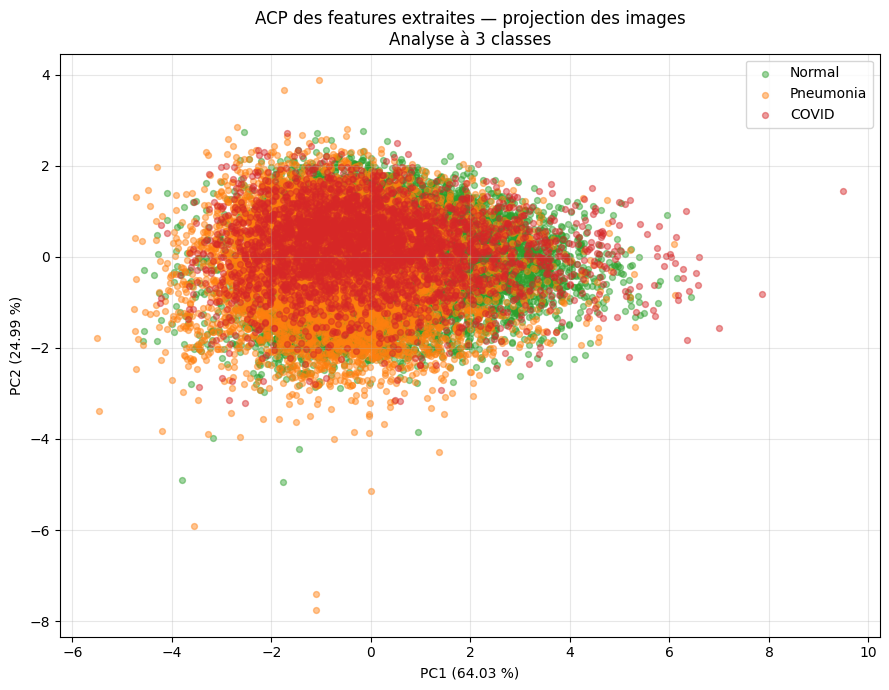

In [23]:
# Projection des individus — analyse à 3 classes

colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Pneumonia": "#ff7f0e"
}

classes_pca = [
    "Normal",
    "Pneumonia",
    "COVID"
]

plt.figure(figsize=(9, 7))

for class_name in classes_pca:

    subset = df_pca[
        df_pca["classe"] == class_name
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=class_name,
        color=colors[class_name],
        alpha=0.45,
        s=18
    )

plt.title(
    "ACP des features extraites — projection des images\n"
    "Analyse à 3 classes"
)

plt.xlabel(
    f"PC1 "
    f"({pca.explained_variance_ratio_[0] * 100:.2f} %)"
)

plt.ylabel(
    f"PC2 "
    f"({pca.explained_variance_ratio_[1] * 100:.2f} %)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

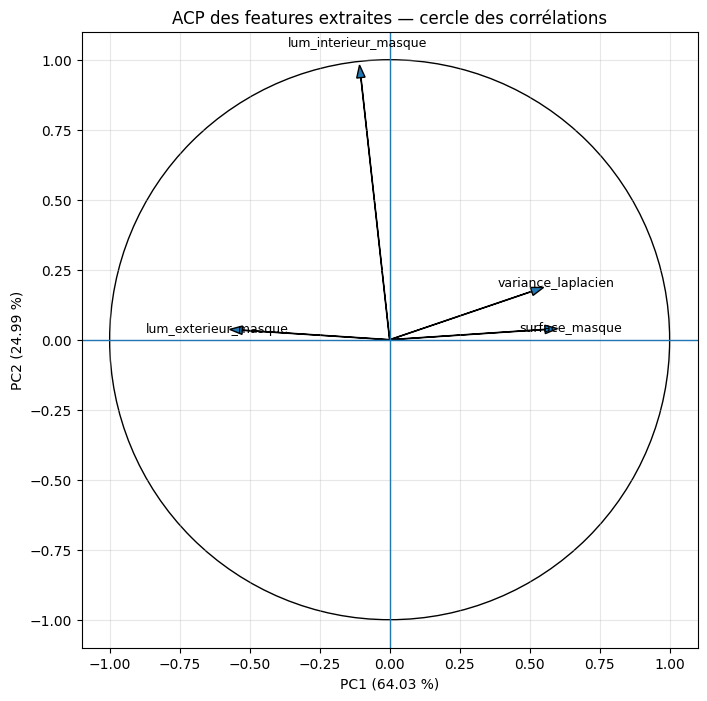

In [24]:
# vecteurs des variables

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features_cols
)

plt.figure(figsize=(8, 8))

# Cercle des corrélations
circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_artist(circle)

for feature in features_cols:
    x = loadings.loc[feature, "PC1"]
    y_var = loadings.loc[feature, "PC2"]

    plt.arrow(
        0, 0,
        x, y_var,
        head_width=0.03,
        length_includes_head=True
    )

    plt.text(
        x * 1.08,
        y_var * 1.08,
        feature,
        ha="center",
        va="center",
        fontsize=9
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f} %)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f} %)")

plt.title("ACP des features extraites — cercle des corrélations")
plt.grid(alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

## Heatmap des corrélations

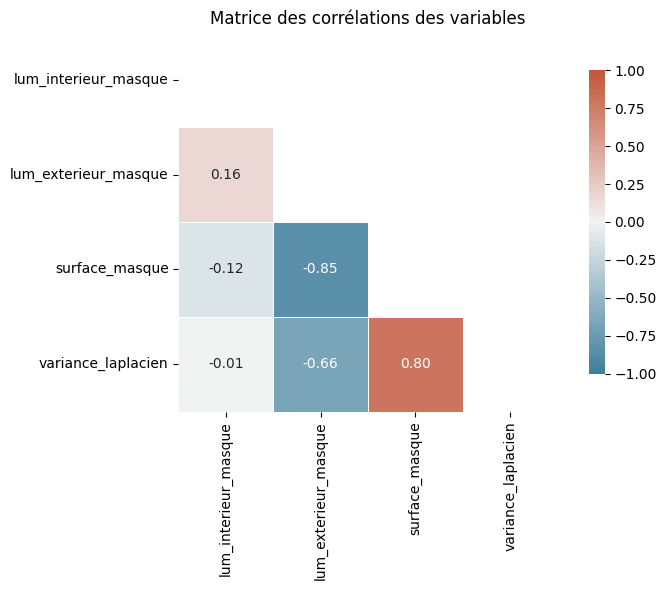

In [25]:
# Variables numériques
features_cols = [
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

# Matrice de corrélations
corr = df_all_features[features_cols].corr()

# Masque pour masquer la moitié supérieure
mask = np.triu(np.ones_like(corr, dtype=bool))

# Figure
plt.figure(figsize=(8,6))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Matrice des corrélations des variables")
plt.tight_layout()
plt.show()